## Import Libraries

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import shap

## Data Cleaning

**Objective:** Before feeding data into a machine learning model, we must clean it and understand the behavioral trends of our customers. 
* We will drop unique identifiers (`RowNumber`, `CustomerId`, `Surname`) because they carry no predictive power and can introduce noise to the model.

In [38]:
df = pd.read_csv("Churn_Modelling.csv")

In [39]:
print("Original Shape: ", df.shape)

Original Shape:  (10000, 14)


In [40]:
# Remove columns that have no predictive power
drop_columns = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns = drop_columns)

In [41]:
# Print clean shape
print("Cleaned Shape: ", df_clean.shape)
display(df_clean.head())

Cleaned Shape:  (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## EDA 

**Objective:** We will visualize the data to establish a baseline understanding of *who* is churning.

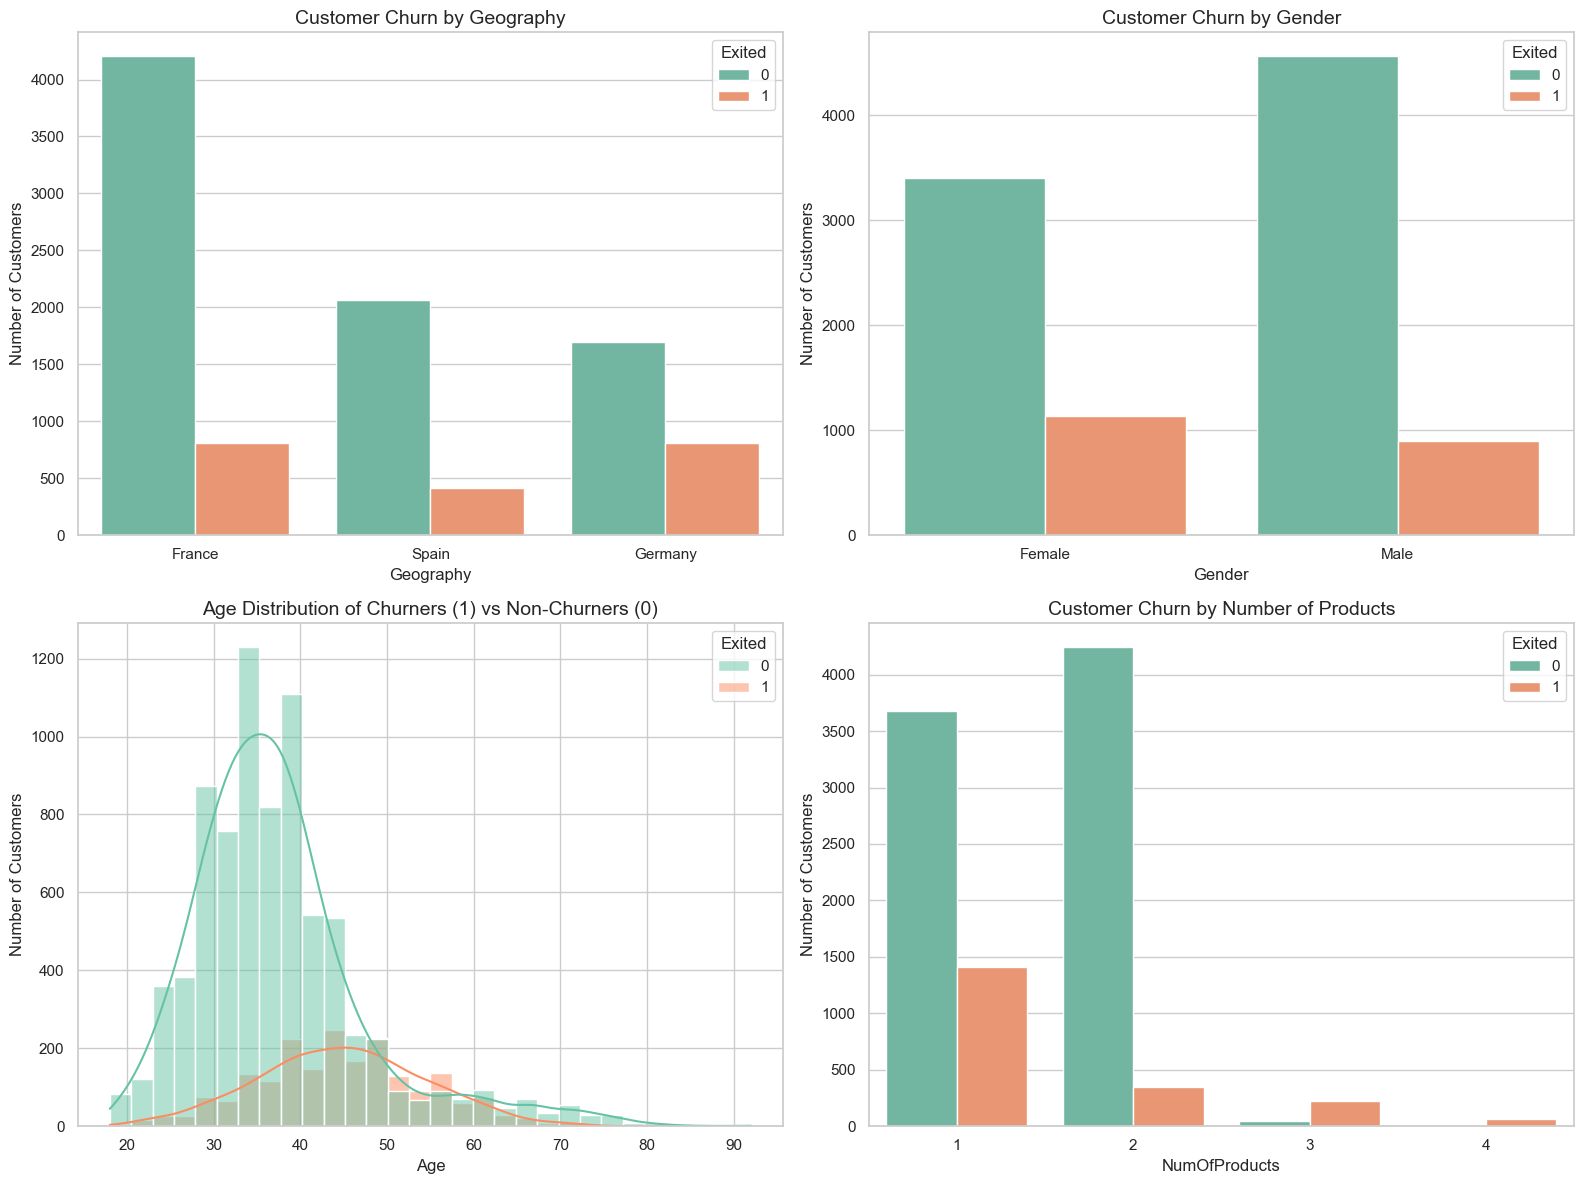

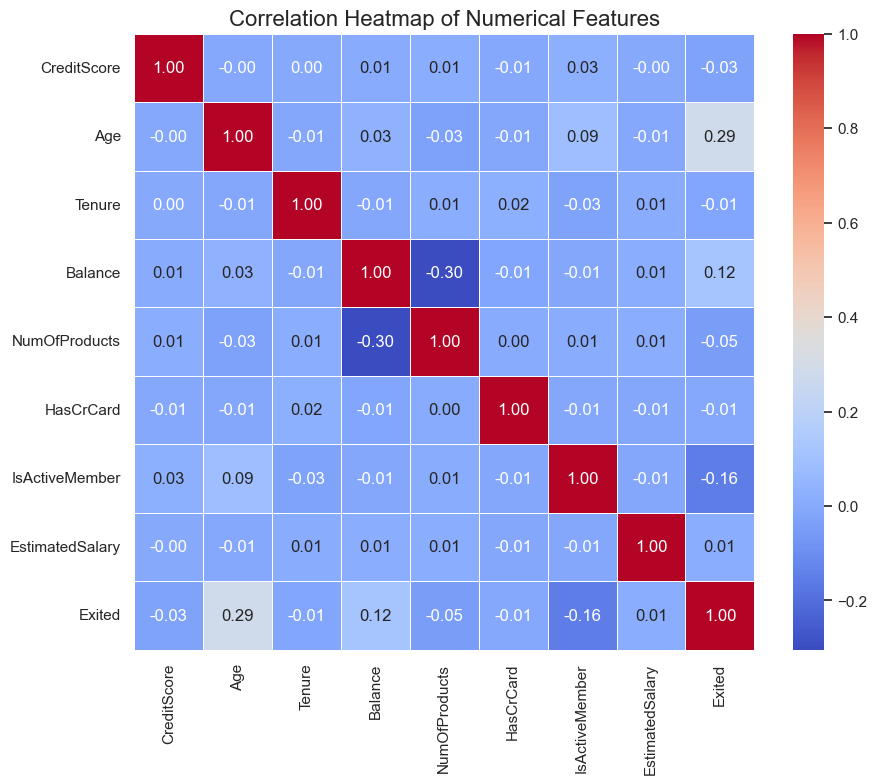

In [42]:
# Set the visual style for our charts
sns.set_theme(style="whitegrid")

# Create a 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Churn by Geography - Are customers from certain countries leaving faster?
sns.countplot(x='Geography', hue='Exited', data=df_clean, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Customer Churn by Geography', fontsize=14)
axes[0, 0].set_ylabel('Number of Customers')

# Churn by Gender - Do males or females churn more?
sns.countplot(x='Gender', hue='Exited', data=df_clean, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Customer Churn by Gender', fontsize=14)
axes[0, 1].set_ylabel('Number of Customers')

# Age Distribution by Churn - Are older or younger customers more likely to leave?
sns.histplot(data=df_clean, x='Age', hue='Exited', kde=True, ax=axes[1, 0], palette='Set2', bins=30)
axes[1, 0].set_title('Age Distribution of Churners (1) vs Non-Churners (0)', fontsize=14)
axes[1, 0].set_ylabel('Number of Customers')

# Churn by Number of Products -If a customer has more products do they stay?
sns.countplot(x='NumOfProducts', hue='Exited', data=df_clean, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Customer Churn by Number of Products', fontsize=14)
axes[1, 1].set_ylabel('Number of Customers')

# Adjust layout so labels don't overlap and show the plots
plt.tight_layout()
plt.show()

# Let's look at how the numerical features relate to each other
plt.figure(figsize=(10, 8))
# Select only numerical columns for the correlation matrix
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_clean[numerical_cols].corr()

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

#### EDA Findings:
Based on the visualizations above, we can identify several high-risk segments:
1. **Age:** The churn distribution peaks at a higher age than the retention distribution. Older demographics are leaving at an accelerated rate.
2. **Geography:** Customers in Germany have a disproportionately high churn rate compared to France and Spain.
3. **Product Saturation:** Almost 100% of customers with 3 or 4 products churned. Our multi-product bundles may be poorly priced or too complex.
4. **Engagement:** "Inactive" members churn far more frequently than active ones.

## Feature Engineering

**Objective:** Machine learning models look at individual columns, but human behavior is often driven by the *relationship* between data points. We will engineer custom features to capture this distinction:
* **Balance-to-Salary Ratio:** Determines how much of a customer's liquid wealth is parked with us.
* **Products-per-Tenure:** Measures how aggressively a customer adopted products over time.
* **Age Grouping:** Bins continuous age data into specific life-stages.

Finally, we will One-Hot Encode categorical text into binary numbers and Scale the numerical data to prevent magnitude bias.

In [43]:
# Ratio A: Balance to Salary Ratio
# A customer with a $50k balance and a $50k salary might behave very differently 
# than a customer with a $50k balance and a $200k salary. This ratio tells us how much 
# of their assumed wealth is parked in this specific bank.
df_clean['BalanceSalaryRatio'] = df_clean['Balance'] / df_clean['EstimatedSalary']

# Ratio B: Products per Year of Tenure
# If a customer has been with the bank for 10 years and has 2 products, they are steady. 
# If they have been there 1 year and have 4 products, they might be overwhelmed or 
# taking advantage of a sign-up bonus before churning. 
# We add "+ 1" to the denominator to prevent a "Divide by Zero" error for customers with 0 years of tenure.
df_clean['ProductsPerTenure'] = df_clean['NumOfProducts'] / (df_clean['Tenure'] + 1)

# Instead of the model treating age 31 and age 32 as totally different numbers, 
# it's often more useful to group them. A 31-year-old and a 39-year-old likely share 
# similar life/financial stages.
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'], 
    bins=[18, 30, 40, 50, 60, 100], # The dividing lines for the age brackets
    labels=['18-30', '31-40', '41-50', '51-60', '60+'] # The names of our new buckets
)

# Create a new column for each category. 
df_encoded = pd.get_dummies(df_clean, columns=['Geography', 'Gender', 'AgeGroup'], drop_first=True)

scaler = StandardScaler()

# In our data: 'Age' ranges from 18 to 90. 'Balance' ranges from 0 to 250,000.
# Some models will look at a Balance of 100,000 
# and assume it is 10,000 times more "important" than an Age of 10 simply because the number is bigger.
# StandardScaler fixes this by squishing all numerical columns to a similar scale 

# Columns that contain regular numbers
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductsPerTenure']

## Modeling and Evaluation Metrics

**Objective:** Train multiple machine learning algorithms to predict churn. 

**Handling Imbalance:** Only ~20% of the dataset churned. If a model guesses "No Churn" for everyone, it is 80% accurate but entirely useless to the business. Therefore, we will evaluate models based on **Recall** (catching the actual churners) and **ROC-AUC** (ability to rank risk), using algorithm-level class weights to penalize the model for missing churners.

In [44]:
# SEPARATE FEATURES AND TARGET
# X contains all our clues (Age, Balance, Geography, etc.)
X = df_encoded.drop('Exited', axis=1)

# y is the answer key we are trying to predict (1 = Churned, 0 = Stayed)
y = df_encoded['Exited']

# 2. TRAIN / TEST SPLIT
# We must hide 20% of our data from the models so we can test them later 
# on "unseen" customers.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. FEATURE SCALING
scaler = StandardScaler()

# List of numerical columns to scale
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductsPerTenure']

# Fit only on the training data, then transform both sets, prevents data leakage.
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


# 4. INITIALIZE MODELS
models = {
    # 1. Set a minimum benchmark.
    # class_weight='balanced': Tells the math to pay 4x more attention to the minority class (Churners).
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    
    # 2. Builds hundreds of decision trees and averages their votes. 
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    
    # 3. Gradient Boosting models (XGBoost & LightGBM)
    "XGBoost": XGBClassifier(scale_pos_weight=4, random_state=42), 
    
    "LightGBM": lgb.LGBMClassifier(class_weight='balanced', random_state=42)
}


# 5. TRAIN AND EVALUATE
results = []

for name, model in models.items():
    # 1. Train the model
    model.fit(X_train, y_train)
    
    # 2. Make hard predictions (0 or 1)
    y_pred = model.predict(X_test)
    
    # 3. Make soft predictions (Probability from 0.0 to 1.0)
    # [:, 1] grabs the probability specifically for class 1 (Churn)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # EVALUATION METRICS EXPLAINED
    results.append({
        "Model": name,
        
        # ACCURACY: % of total correct guesses.
        "Accuracy": accuracy_score(y_test, y_pred),
        
        # PRECISION: Out of everyone the model *said* would churn, how many actually did?
        "Precision": precision_score(y_test, y_pred),
        
        # RECALL: Out of everyone who *actually* churned, how many did the model find?
        "Recall": recall_score(y_test, y_pred), 
        
        # F1 SCORE: The harmonic mean between Precision and Recall.
        "F1 Score": f1_score(y_test, y_pred),
        
        # ROC-AUC: Measures the model's ability to rank risk. 
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    
    # Convert the results dictionary into a pretty pandas DataFrame
results_df = pd.DataFrame(results).set_index("Model")
print("\n--- Model Evaluation ---")
display(results_df.round(3))

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1153
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

--- Model Evaluation ---


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.727,0.404,0.715,0.516,0.795
Random Forest,0.858,0.786,0.415,0.543,0.852
XGBoost,0.825,0.562,0.636,0.597,0.834
LightGBM,0.814,0.533,0.717,0.612,0.860


#### Modeling Findings:
* **Tree-based models (LightGBM, XGBoost, Random Forest)** significantly outperformed the Logistic Regression baseline. 
* This proves that customer churn behavior is highly non-linear, it spikes at certain life stages.
* We will move forward with **LightGBM** as our primary model due to its high Recall/ROC-AUC and excellent compatibility with explainability tools. 

## Model Explainability (SHAP)

**Objective:** Advanced models can flag at-risk customers, but the retention team needs to know why they are leaving to stop it. We use SHAP to crack open the AI's "black box," pinpointing the exact reasons behind a customer's decision to churn so we can intervene with targeted, data-driven solutions.


--- SHAP Summary Plot ---


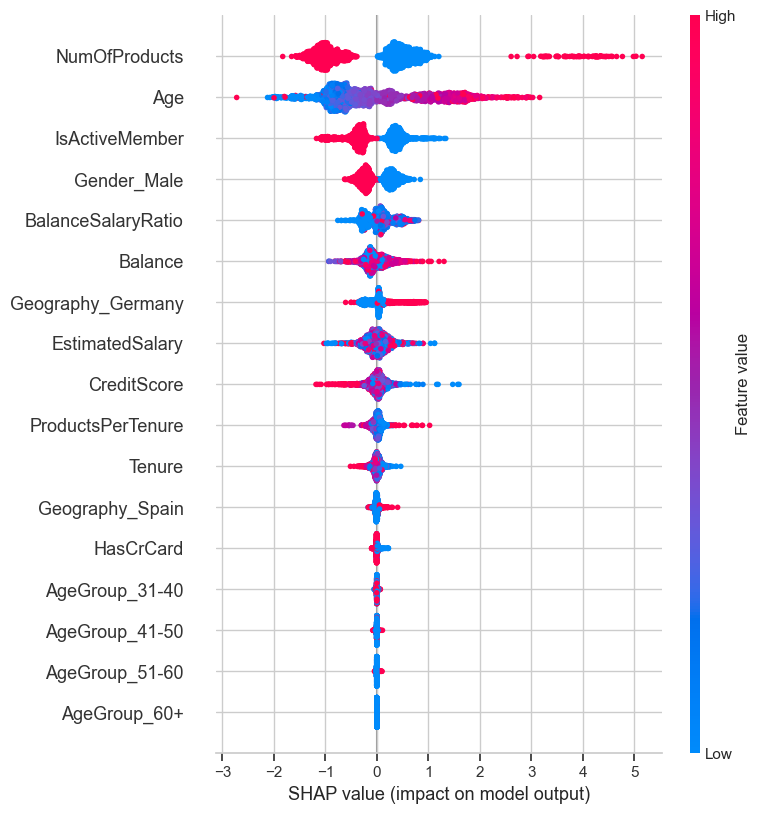

In [45]:
# Hide warning (Is not a real error)
import warnings
warnings.filterwarnings("ignore", message="LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray")

# We will use our LightGBM model because tree-based models work perfectly with SHAP's TreeExplainer.
best_model = models["LightGBM"]

explainer = shap.TreeExplainer(best_model)

# We pass in our test data to see how the model made its decisions on unseen customers.
shap_values = explainer.shap_values(X_test)

# Note: For binary classification (0 or 1), LightGBM sometimes returns a list of two arrays 
# (one for 'Stayed', one for 'Churned'). We only care about the 'Churned' explanations (index 1).
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

# Visualize a summary plot
print("\n--- SHAP Summary Plot ---")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_churn, X_test, plot_type="dot")

## Final Business Insights:
The SHAP summary plot proves exactly how the AI makes its decisions. By looking at the feature impact, we can definitively tell stakeholders:
1. **Age:** High age (red dots) heavily pushes the model to predict churn.
2. **Engagement:** Low activity (blue dots on `IsActiveMember`) is the second strongest driver of churn.
3. **Products:** A high number of products (red dots) pushes the model toward a positive churn prediction.

**Strategic Recommendation:** The bank should immediately launch a targeted re-engagement campaign (special rates, personalized check-ins) specifically aimed at **older, inactive customers**, and audit the pricing structure for users holding 3+ products.